# Wine Quality Prediction using Machine Learning

## Objective
The goal of this project is to predict the quality of wine based on its physicochemical properties.

This can help in quality control and production optimization.

Importing the dependencies

In [152]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

Data Collection

In [153]:
# loading the dataset to a pandas dataframe
wine_dataset  = pd.read_csv("data/winequality-red.csv")

In [154]:
# number of rows and column in the dataframe
wine_dataset.shape

(1599, 12)

In [155]:
wine_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Dataset Description

The dataset contains chemical properties of wine such as:

- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- alcohol

Target variable:
- quality (score from 0–10)

In [156]:
# checking missing values
wine_dataset.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Data Analysis and Visualiastion

In [157]:
# statistical data of the dataset
wine_dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [158]:
wine_dataset['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


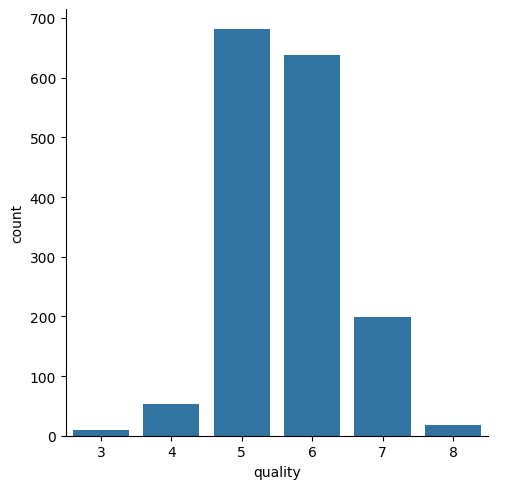

In [159]:
# number of values for each quality
sns.catplot(x="quality",data = wine_dataset, kind="count")

<Axes: xlabel='quality', ylabel='volatile acidity'>

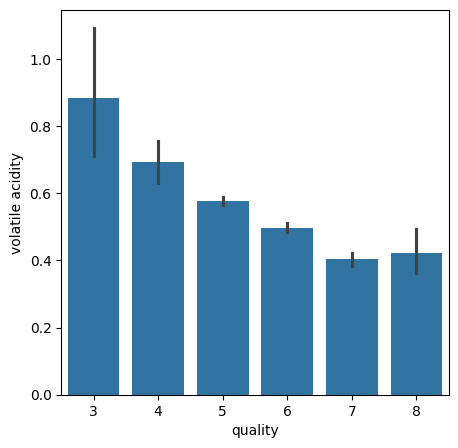

In [160]:
# volatile acidity vs quality
plot = plt.figure(figsize=(5,5))
sns.barplot(x="quality" , y="volatile acidity" ,data = wine_dataset)

<Axes: xlabel='quality', ylabel='citric acid'>

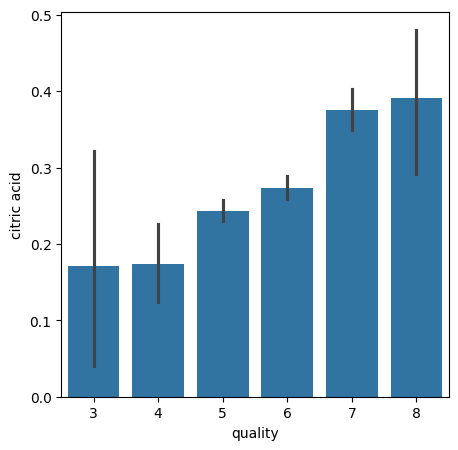

In [161]:
# citirc acid vs quality
plot = plt.figure(figsize=(5,5))
sns.barplot(x="quality" , y="citric acid" ,data = wine_dataset)

Correlation

1. Positive Correlation
2. Negative Correlation

In [162]:
correlation = wine_dataset.corr()

<Axes: >

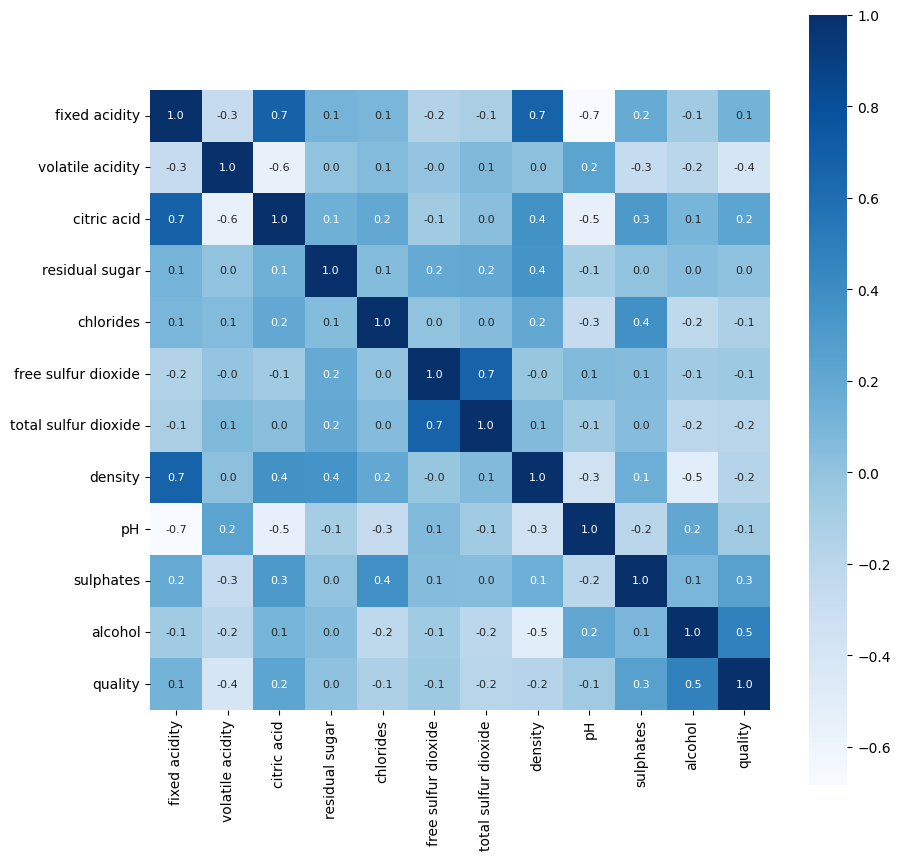

In [163]:
# constructing a heatmap to understand the correlation between the columns
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True , square=True, fmt=".1f", annot=True , annot_kws={"size":8},cmap="Blues")

Data Preprocessing

In [164]:
X = wine_dataset.drop("quality",axis=1)
Y = wine_dataset["quality"]

In [165]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [166]:
print("Feature shape:", X.shape)
print("Target shape:", Y.shape)

Feature shape: (1599, 11)
Target shape: (1599,)


train and test split

In [167]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [168]:
print(X.shape,X_train.shape,X_test.shape)

(1599, 11) (1279, 11) (320, 11)


Model Training : Random Classifier Model

In [169]:
model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=42
)

In [170]:
model.fit(X_train,Y_train)

RandomForestRegressor(max_depth=10, n_estimators=400, random_state=42)

In [171]:
training_data_prediction = model.predict(X_train)

In [172]:
mae = mean_absolute_error(Y_train, training_data_prediction)
mse = mean_squared_error(Y_train, training_data_prediction)
r2 = r2_score(Y_train, training_data_prediction)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 0.23893604028005527
Mean Squared Error: 0.09784128872325892
R2 Score: 0.8522713253662975


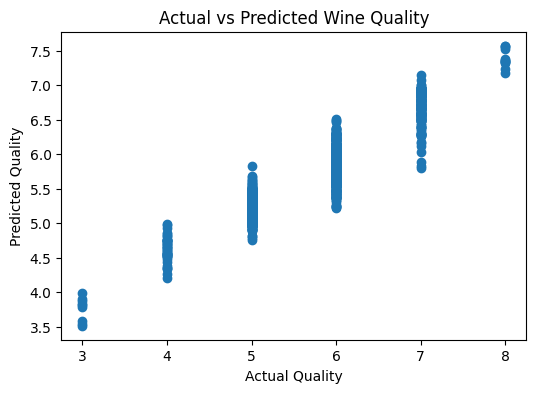

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(Y_train, training_data_prediction)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")

plt.title("Actual vs Predicted Wine Quality")

plt.show()

In [174]:
test_data_prediction = model.predict(X_test)

In [175]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, test_data_prediction)
mse = mean_squared_error(Y_test, test_data_prediction)
r2 = r2_score(Y_test, test_data_prediction)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 0.4578479339948487
Mean Squared Error: 0.3639319564686481
R2 Score: 0.3984498661459934


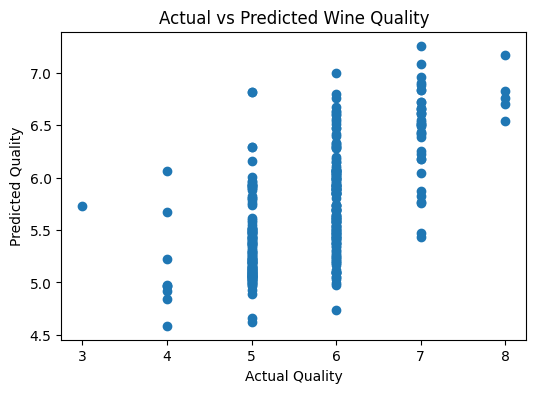

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(Y_test,test_data_prediction)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()

### Model Performance Interpretation

The Random Forest model predicts wine quality with improved accuracy compared to simpler models.

R² score indicates that the model captures a reasonable amount of variance in wine quality.

However, predicting exact quality is difficult because:

- taste perception is subjective  
- chemical features do not fully represent human sensory evaluation  

The model is effective for identifying general quality trends.


Building a predictive System

In [177]:
# input_data = (X.iloc[1])
input_data = (7.3,0.65,0.0,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0)
input_df = pd.DataFrame([input_data], columns=X.columns)

input_data_scaled = pd.DataFrame(
    scaler.transform(input_df),
    columns=X.columns)

prediction = model.predict(input_data_scaled)

if prediction[0] >= 6:
    print("Good Quality Wine")
else:
    print("Bad Quality Wine")

print("Predicted Wine Quality:", prediction[0])

Bad Quality Wine
Predicted Wine Quality: 4.88894094958785


## Conclusion

This project predicts wine quality using Random Forest Regression.

Key observations:

- alcohol content is one of the most important features  
- acidity levels also influence wine quality  
- ensemble methods like Random Forest improve prediction performance  

Limitations:

- wine quality is subjective  
- dataset features do not capture full sensory experience  

Future improvements:

- hyperparameter tuning  
- try XGBoost  
- convert to classification problem  